In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "dataset.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9709 entries, 0 to 9708
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               9709 non-null   int64  
 1   Gender           9709 non-null   int64  
 2   Own_car          9709 non-null   int64  
 3   Own_property     9709 non-null   int64  
 4   Work_phone       9709 non-null   int64  
 5   Phone            9709 non-null   int64  
 6   Email            9709 non-null   int64  
 7   Unemployed       9709 non-null   int64  
 8   Num_children     9709 non-null   int64  
 9   Num_family       9709 non-null   int64  
 10  Account_length   9709 non-null   int64  
 11  Total_income     9709 non-null   float64
 12  Age              9709 non-null   float64
 13  Years_employed   9709 non-null   float64
 14  Income_type      9709 non-null   object 
 15  Education_type   9709 non-null   object 
 16  Family_status    9709 non-null   object 
 17  Housing_type  

(None,
         ID  Gender  Own_car  Own_property  Work_phone  Phone  Email  \
 0  5008804       1        1             1           1      0      0   
 1  5008806       1        1             1           0      0      0   
 2  5008808       0        0             1           0      1      1   
 3  5008812       0        0             1           0      0      0   
 4  5008815       1        1             1           1      1      1   
 
    Unemployed  Num_children  Num_family  Account_length  Total_income  \
 0           0             0           2              15      427500.0   
 1           0             0           2              29      112500.0   
 2           0             0           1               4      270000.0   
 3           1             0           1              20      283500.0   
 4           0             0           2               5      270000.0   
 
          Age  Years_employed           Income_type  \
 0  32.868574       12.435574               Working   
 1 

In [57]:
#################################################################################
# Data Preprocessing
from sklearn.preprocessing import MinMaxScaler

# One-hot encoding categorical variables(convert categorial variables into numerical formats)
df_encoded = pd.get_dummies(df, columns=['Income_type', 'Education_type', 'Family_status', 'Housing_type', 'Occupation_type'], drop_first=True)

# Normalization of numerical (Between 0 and 1)
scaler = MinMaxScaler()
numerical_cols = ['Total_income', 'Age', 'Years_employed', 'Account_length']
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
# Make the value range of all features similar to avoid uneven influence of features(i.e., Avoid certain large numerical features (such as Total_income) dominating other features.)

# Display processed data
display(df_encoded.head())  # If using Jupyter Notebook
df_encoded.to_csv("processed_dataset.csv", index=False)  # Save as CSV


,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,...,Occupation_type_Low-skill Laborers,Occupation_type_Managers,Occupation_type_Medicine staff,Occupation_type_Other,Occupation_type_Private service staff,Occupation_type_Realty agents,Occupation_type_Sales staff,Occupation_type_Secretaries,Occupation_type_Security staff,Occupation_type_Waiters/barmen staff
0,5008804,1,1,1,1,0,0,0,0,2,...,False,False,False,True,False,False,False,False,False,False
1,5008806,1,1,1,0,0,0,0,0,2,...,False,False,False,False,False,False,False,False,True,False
2,5008808,0,0,1,0,1,1,0,0,1,...,False,False,False,False,False,False,True,False,False,False
3,5008812,0,0,1,0,0,0,1,0,1,...,False,False,False,True,False,False,False,False,False,False
4,5008815,1,1,1,1,1,1,0,0,2,...,False,False,False,False,False,False,False,False,False,False


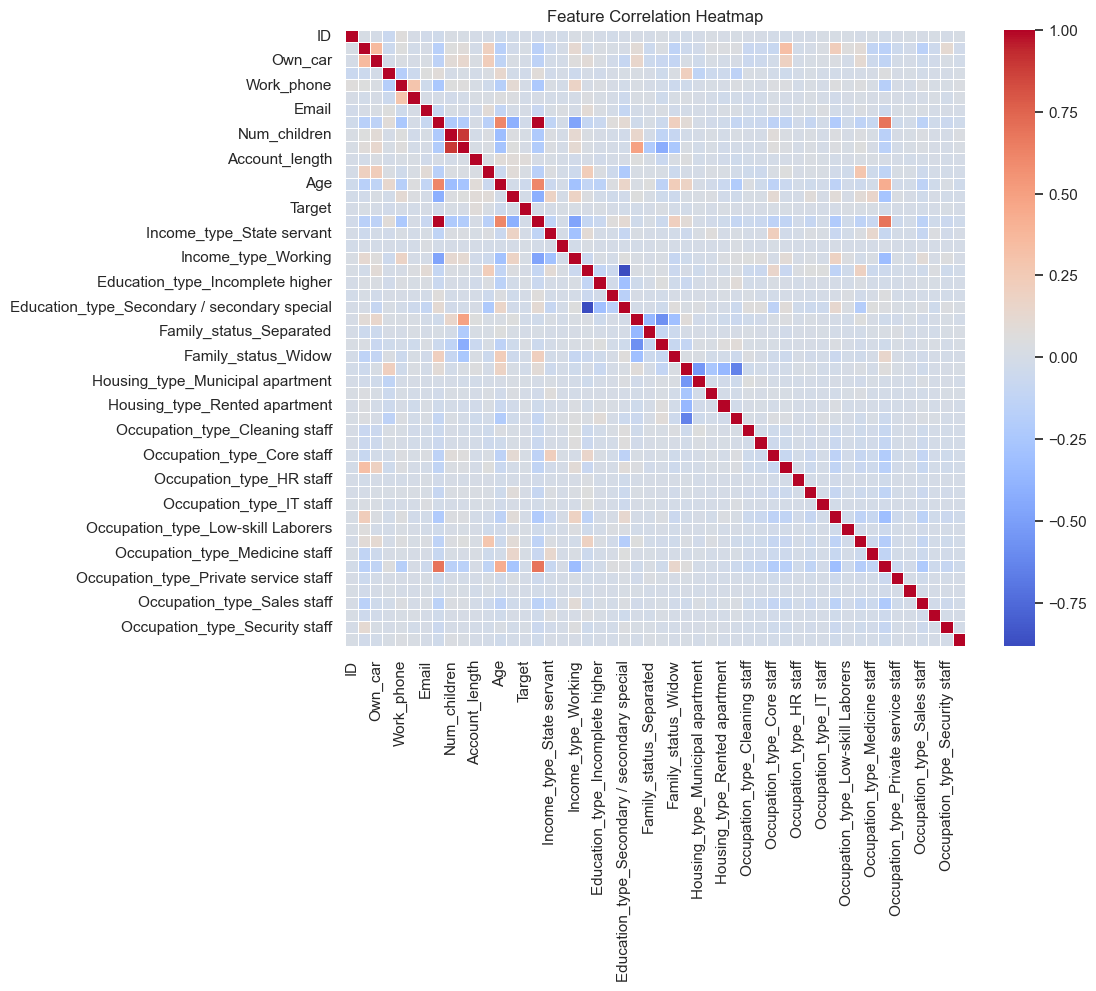

Top correlated features with credit risk (Target):
Target                                1.000000
Account_length                        0.077492
Family_status_Single / not married    0.024908
Education_type_Incomplete higher      0.022170
Total_income                          0.018784
Housing_type_Rented apartment         0.017540
Occupation_type_Low-skill Laborers    0.016496
Gender                                0.015033
Occupation_type_Security staff        0.013342
Occupation_type_Core staff            0.012847
Name: Target, dtype: float64
📌0.00 ~ 0.10: almost no correlation or very weak correlation. 0.10 ~ 0.30: weak correlation. 0.30 ~ 0.50: medium correlation. 0.50 ~ 0.70: strong correlation. 0.70 and above: Strong correlation. The output results show that (except for Target itself) the Pearson correlation coefficient between each feature and credit risk (Target) is very low.


In [59]:
# Correlation Analysis
# Compute correlation 
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df_encoded.corr() # Pearson correlation coefficients were calculated for all numerical features.
target_correlation = correlation_matrix["Target"].sort_values(ascending=False)
# Extract the feature with the highest correlation to Target.

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
# The darker the color, the stronger the correlation (red = positive correlation, blue = negative correlation)

# Show correlations with the target variable
print("Top correlated features with credit risk (Target):")
print(target_correlation.head(10))

print("📌0.00 ~ 0.10: almost no correlation or very weak correlation. 0.10 ~ 0.30: weak correlation. 0.30 ~ 0.50: medium correlation. 0.50 ~ 0.70: strong correlation. 0.70 and above: Strong correlation. The output results show that (except for Target itself) the Pearson correlation coefficient between each feature and credit risk (Target) is very low.")


In [61]:
import scipy.stats as stats

# Chi-Square Test (Categorical Features)
# Define categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
chi2_results = {}

for col in categorical_cols:
    observed = pd.crosstab(df[col], df["Target"])
    chi2, p, dof, expected = stats.chi2_contingency(observed)
    chi2_results[col] = p  # Store p-value

# Show chi-square test results
chi2_df = pd.DataFrame(chi2_results.items(), columns=["Feature", "P-Value"])
print("Chi-square test results (P-Value < 0.05 indicates a significant influence on the target variable):")
print(chi2_df)

print("📌In statistical tests, when p-value is less than 0.05, it is generally considered that there is statistical significance between the feature and the target variable. The output results show that there is no significant correlation between these classification characteristics and credit risk.")


Chi-square test results (P-Value < 0.05 indicates a significant influence on the target variable):
           Feature   P-Value
0      Income_type  0.474975
1   Education_type  0.103672
2    Family_status  0.082387
3     Housing_type  0.368207
4  Occupation_type  0.737677
📌In statistical tests, when p-value is less than 0.05, it is generally considered that there is statistical significance between the feature and the target variable. The output results show that there is no significant correlation between these classification characteristics and credit risk.


In [63]:
print("📌 The correlation coefficient of numerical features and the chi-square test of numerical features show that the ability of individual characteristics to explain credit risk is weak. It is necessary to better identify and predict credit risk by creating new related features and constructing a comprehensive credit scoring model later.")


📌 The correlation coefficient of numerical features and the chi-square test of numerical features show that the ability of individual characteristics to explain credit risk is weak. It is necessary to better identify and predict credit risk by creating new related features and constructing a comprehensive credit scoring model later.


/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3217247078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_encoded["Target"], palette="coolwarm")


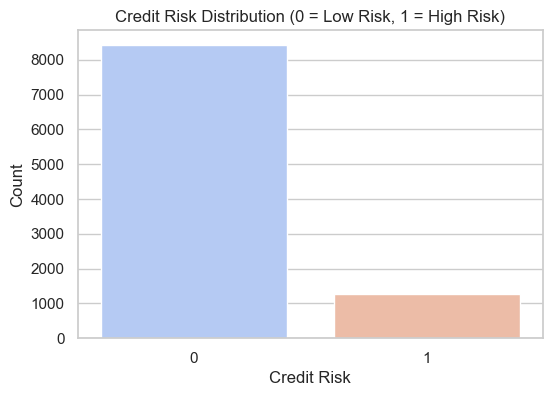

/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3217247078.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="coolwarm", ax=ax)
/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3217247078.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="coolwarm", ax=ax)
/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3217247078.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="coolwarm", ax=ax)
/var/folders/

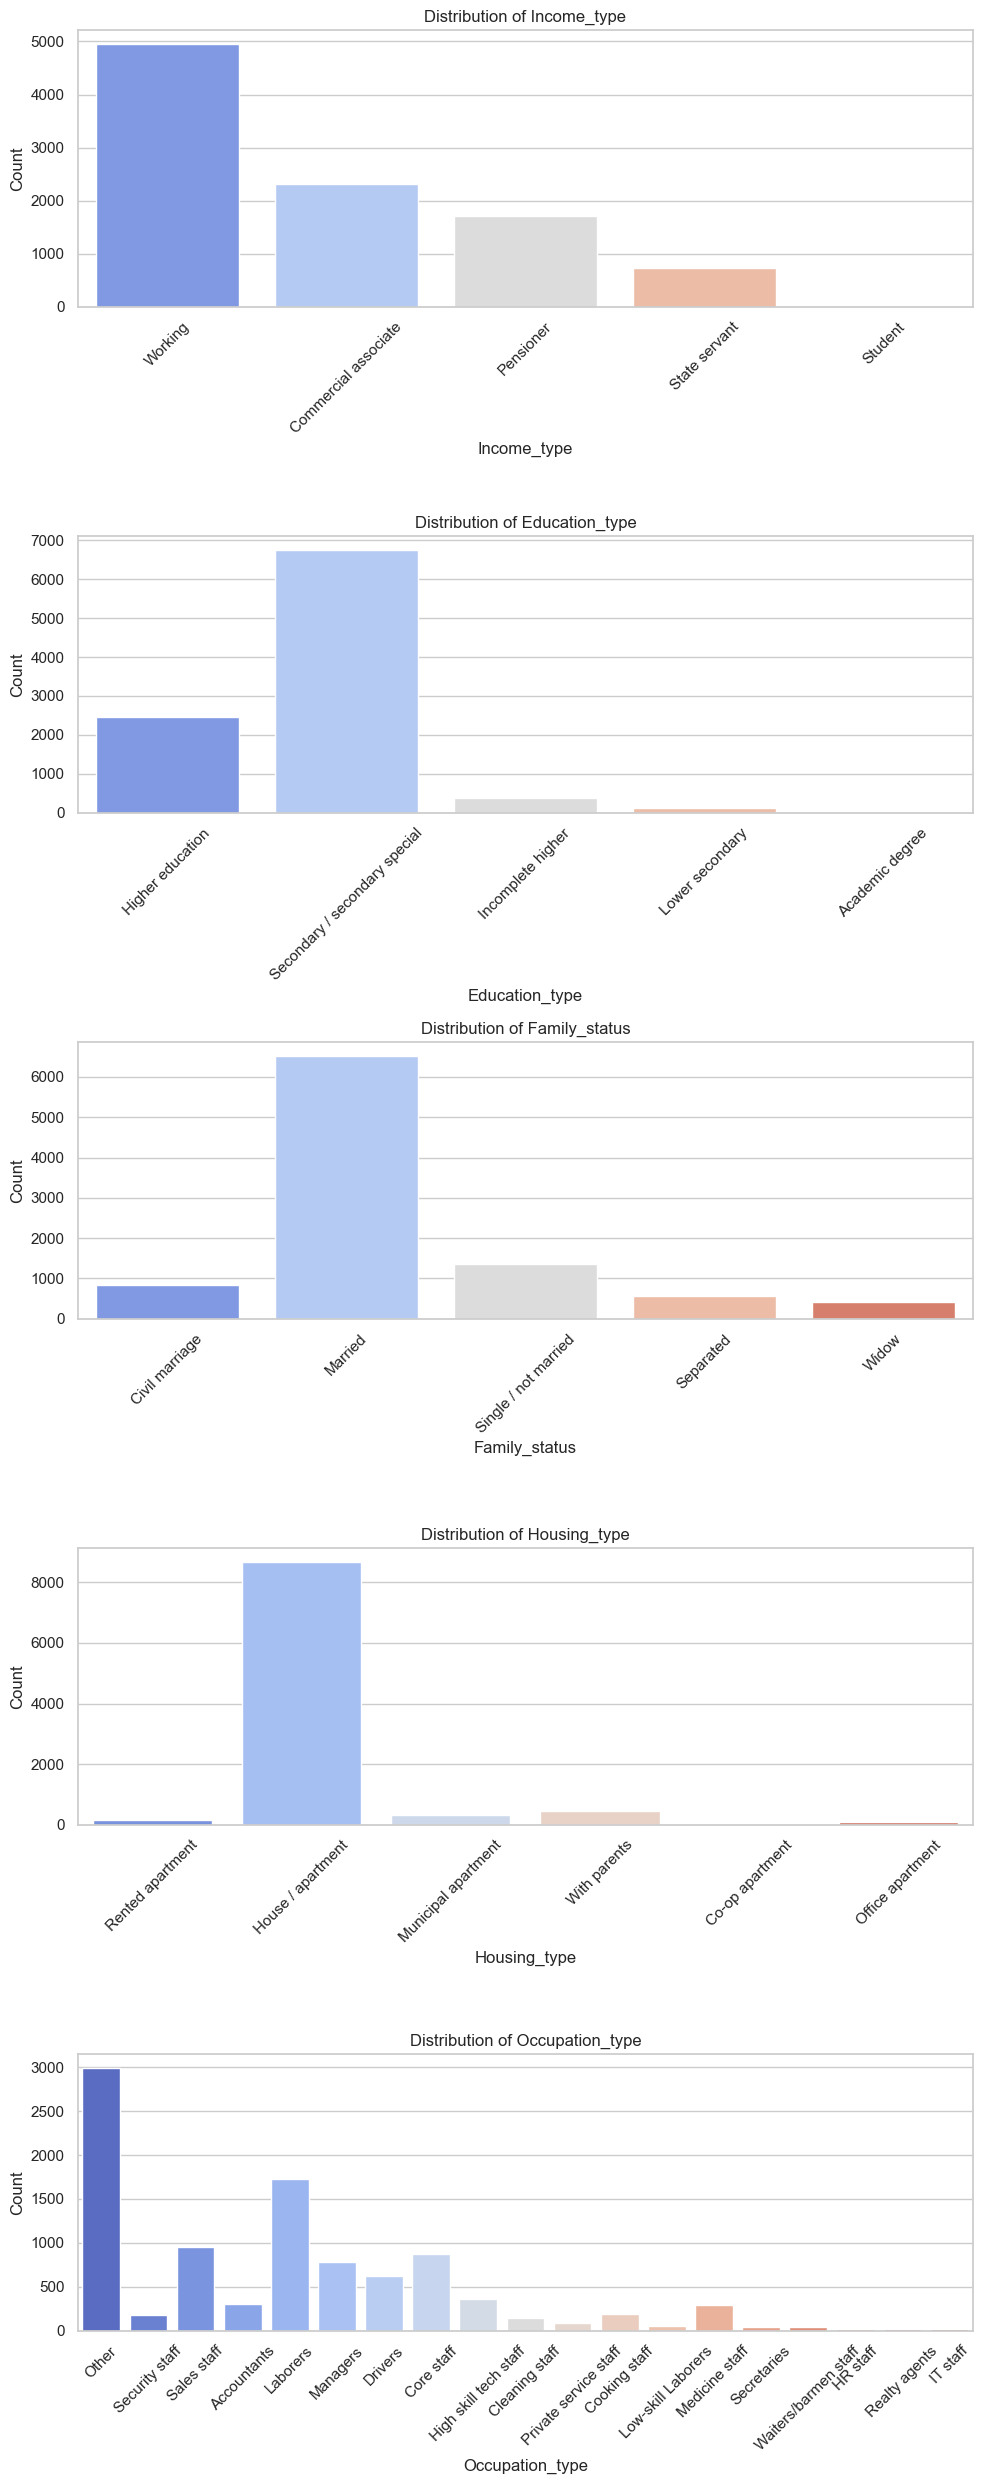

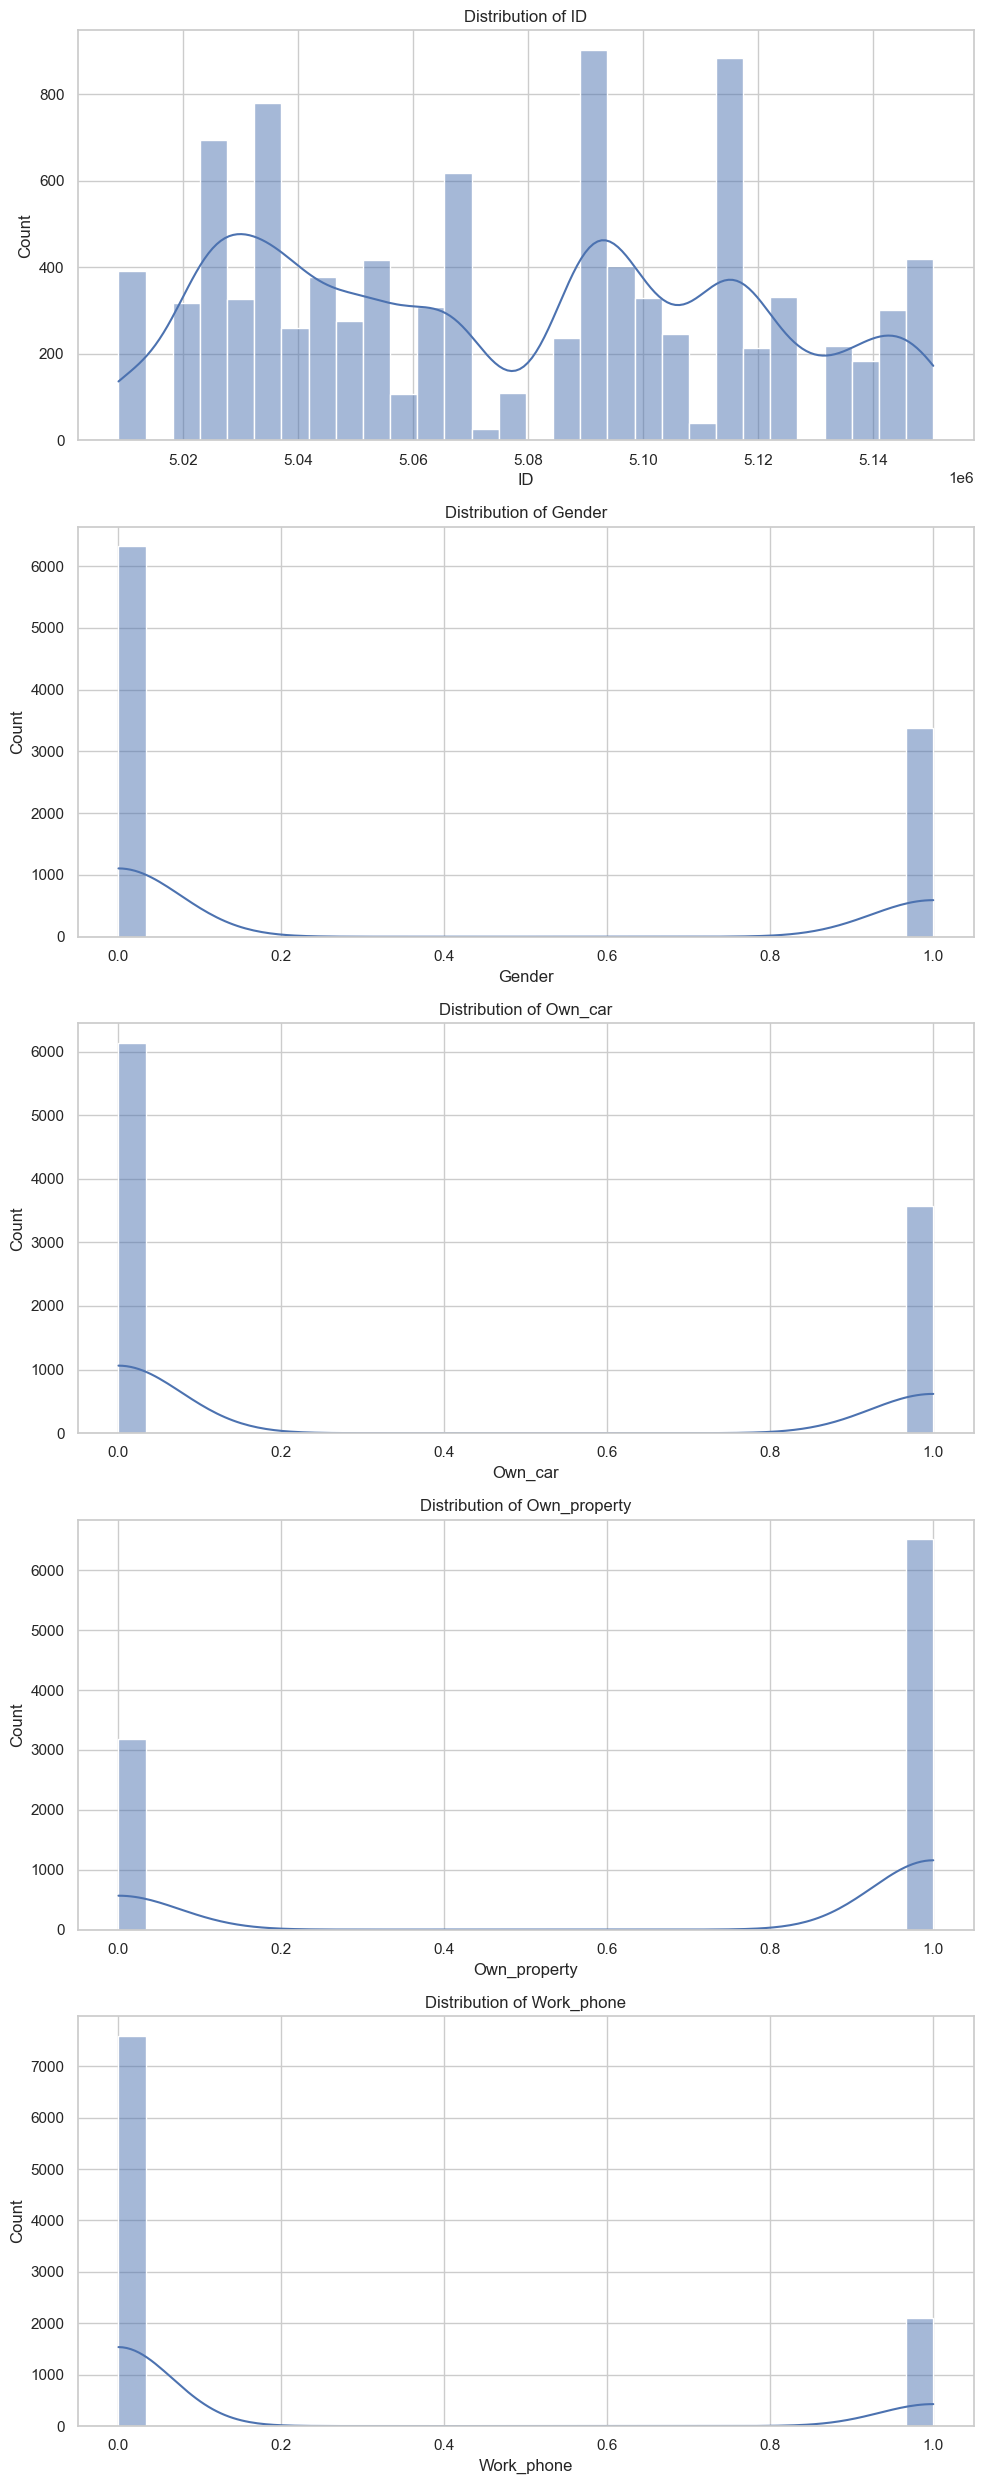

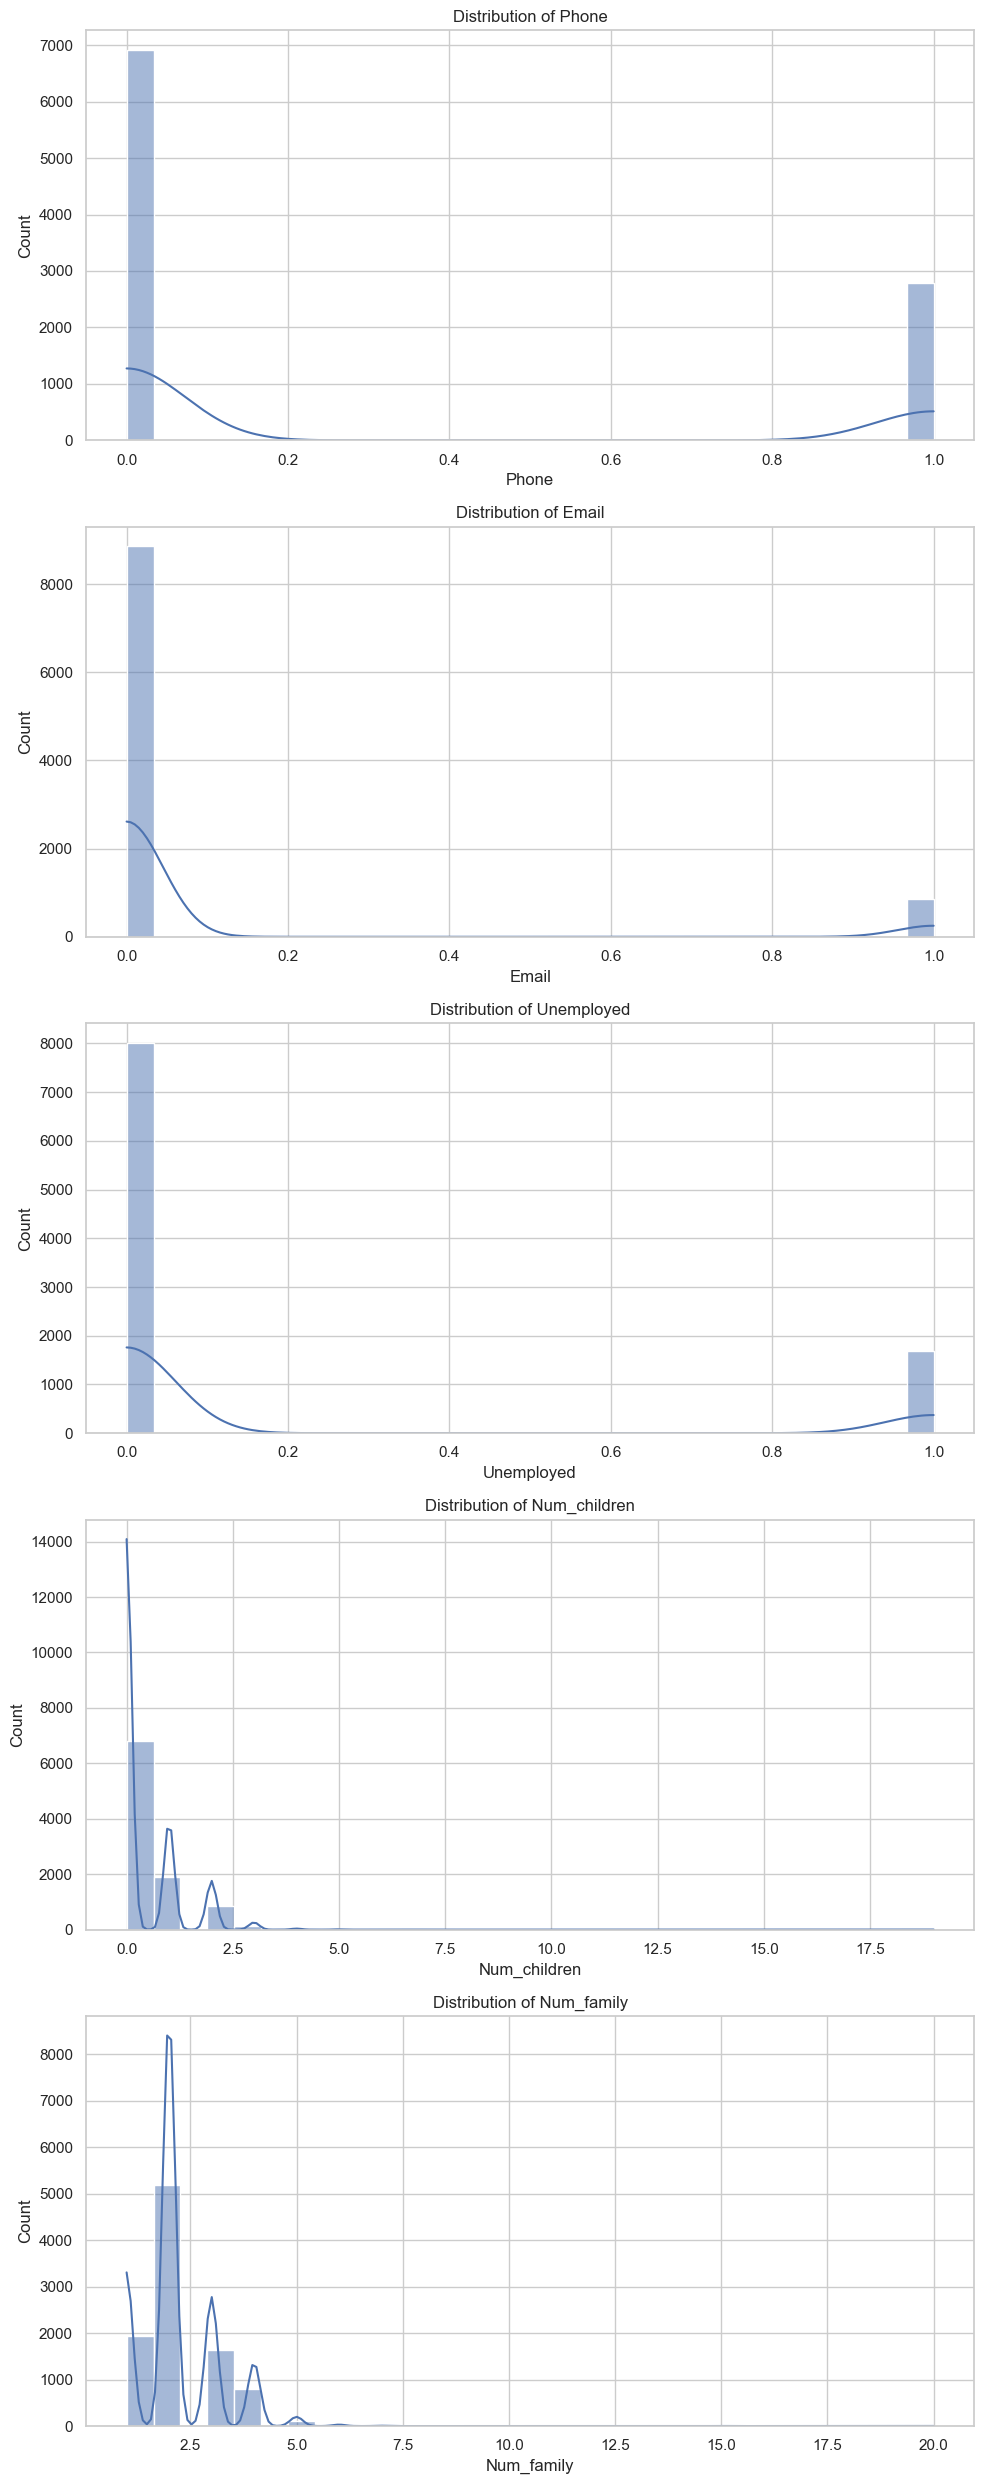

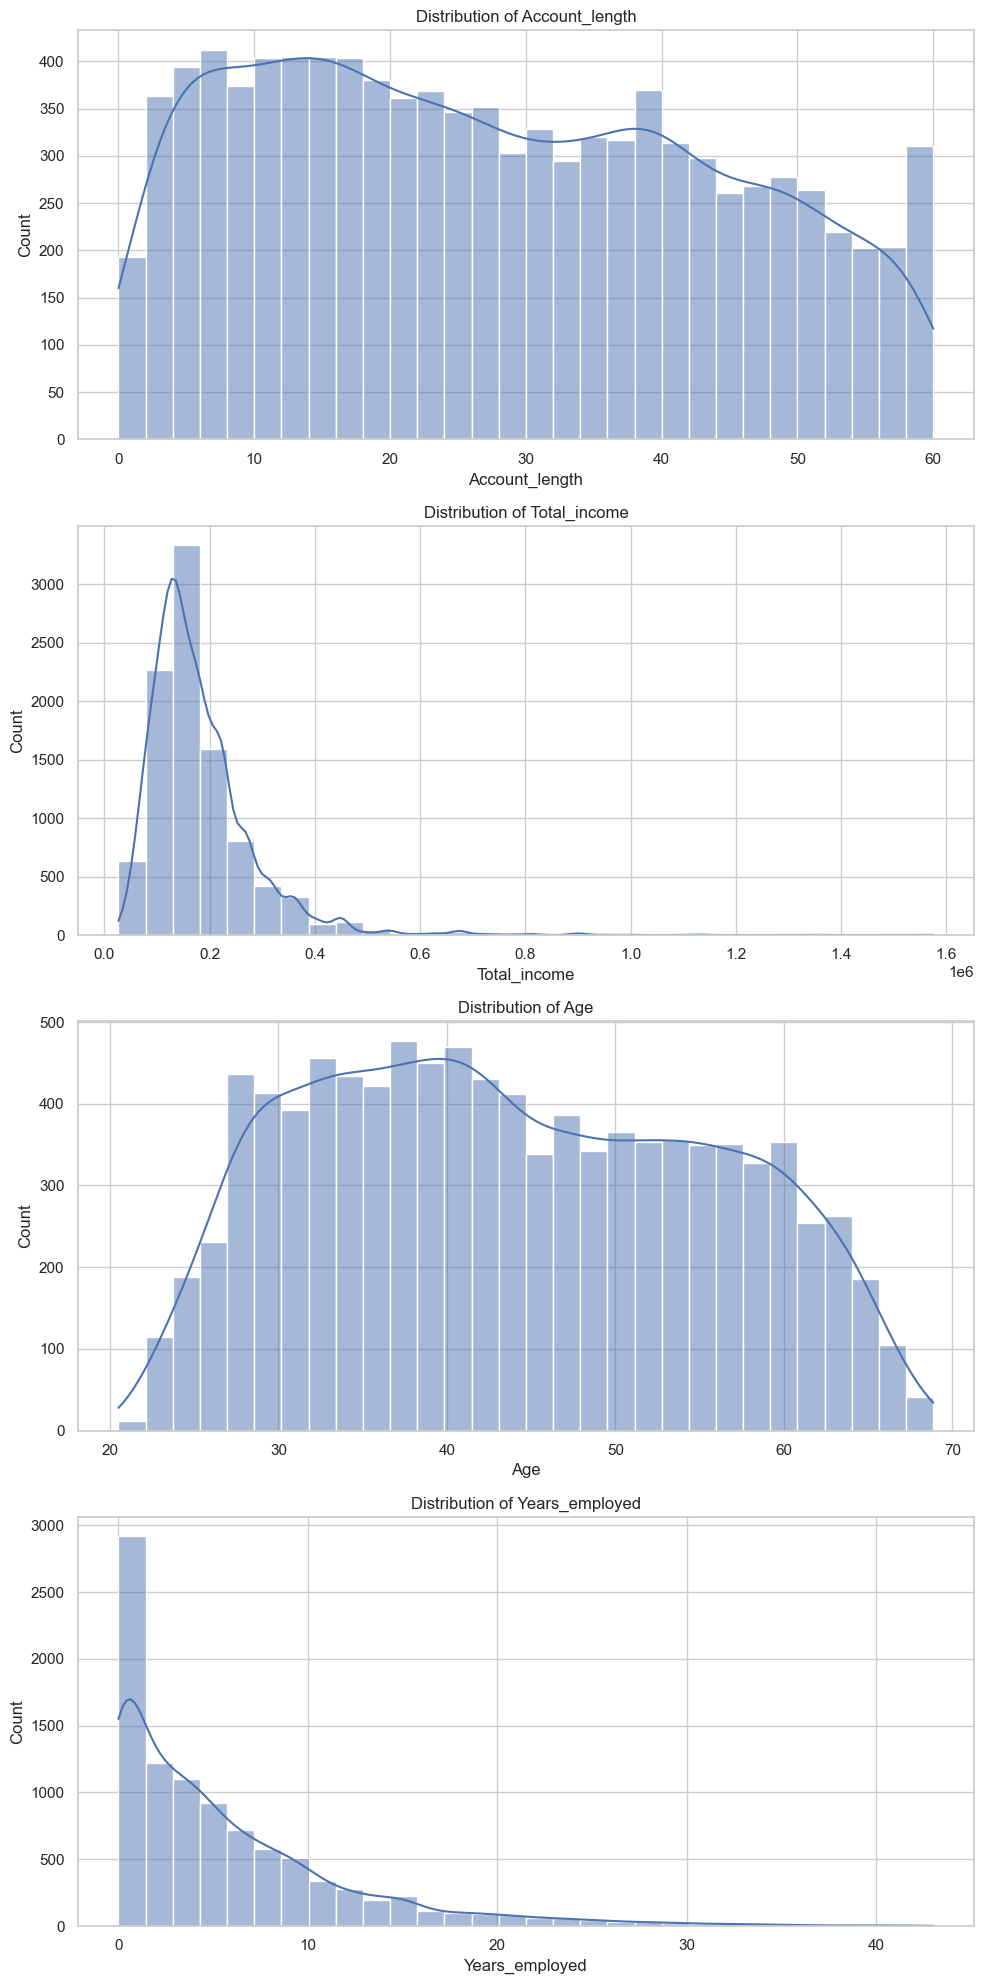

In [65]:
##################################
# Exploratory Data Analysis (EDA):
##################################

# Credit risk distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df_encoded["Target"], palette="coolwarm")
plt.title("Credit Risk Distribution (0 = Low Risk, 1 = High Risk)")
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.show()

# Key feature distributions
# Identify categorical and numerical features
categorical_features = [col for col in df.select_dtypes(include=["object"]).columns.tolist() if col != "Target"]
numerical_features = [col for col in df.select_dtypes(include=["int64", "float64"]).columns.tolist() if col != "Target"]


# Function to plot categorical features in batches
def plot_categorical_features(features, batch_size=5):
    for i in range(0, len(features), batch_size):
        batch = features[i : i + batch_size]
        fig, axes = plt.subplots(len(batch), 1, figsize=(10, 5 * len(batch)))

        # Ensure axes is iterable for single plots
        if len(batch) == 1:
            axes = [axes]

        for ax, feature in zip(axes, batch):
            sns.countplot(data=df, x=feature, palette="coolwarm", ax=ax)
            ax.set_title(f"Distribution of {feature}")
            ax.set_xlabel(feature)
            ax.set_ylabel("Count")
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

# Function to plot numerical features in batches
def plot_numerical_features(features, batch_size=5):
    for i in range(0, len(features), batch_size):
        batch = features[i : i + batch_size]
        fig, axes = plt.subplots(len(batch), 1, figsize=(10, 5 * len(batch)))

        # Ensure axes is iterable for single plots
        if len(batch) == 1:
            axes = [axes]

        for ax, feature in zip(axes, batch):
            sns.histplot(df[feature], bins=30, kde=True, ax=ax)
            ax.set_title(f"Distribution of {feature}")
            ax.set_xlabel(feature)
            ax.set_ylabel("Count")

        plt.tight_layout()
        plt.show()
        
# Call functions to visualize categorical and numerical features
plot_categorical_features(categorical_features, batch_size=5)
plot_numerical_features(numerical_features, batch_size=5)


In [66]:
print("【Observed characteristic patterns】:")

print("📌 📌 「Categorial features (bar chart)」")
print("📌 Income Type: They are mainly Working and Commercial Associate, with fewer students and civil servants.")
print("📌 Education Type: It is mainly Secondary/Secondary Special education, with relatively few higher education.")
print("📌 Family Status: Married people predominate, widows and divorcees are rare.")
print("📌 Housing Type: The vast majority of people live in House/Apartment, with fewer renters.")
print("📌 Occupation Type: Other occupations (not classified) were the most common, with more security and sales workers and fewer in technology industries such as IT.")

print("📌 📌 「Numerical features (histogram)」")
print("📌 Own Car / Own Property: Most don't own cars/homes, which may be associated with credit risk.")
print("Phone/Work phone/Email/Unemployed: Most people don't have phone/Work phone/Email and Unemployed.")
print("Num Family & Num Children: Most people are childless or have two to four family members, with less extreme cases.")
print("📌 Age Distribution: The shape is close to a normal distribution, but slightly to the left, fewer young people. This indicates that the age distribution of individuals in the sample is fairly balanced, which is suitable for most analysis methods.")
print("📌 Account Length Distribution: This distribution is a relatively uniform discrete distribution, which may indicate that the number of new accounts and long-term users is relatively balanced. Further segmentation of the user base (short-term vs long-term accounts) may be required.")
print("📌 Total Income Distribution: Severe dextrism, long tail on the right side. A few have very high incomes, while the majority have low incomes. This long-tail distribution indicates the need for a log transformation to reduce the effects of skewness.")
print("📌 Years Employed Distribution: The height is skewed to the right, indicating that most people have shorter employment years. That could mean many applicants are young or just entering the workforce. This could also affect credit risk assessments, as people with shorter stable jobs may be more likely to default.")

print("📌 The histogram is suitable for numerical variables to view the distribution of the data, and for continuous variables such as Age, Total_income, Years_employed, Account_length, etc. The bar chart applies to category variables (such as occupation, income type, housing type, etc.) to see the frequency of each category.")



【Observed characteristic patterns】:
📌 📌 「Categorial features (bar chart)」
📌 Income Type: They are mainly Working and Commercial Associate, with fewer students and civil servants.
📌 Education Type: It is mainly Secondary/Secondary Special education, with relatively few higher education.
📌 Family Status: Married people predominate, widows and divorcees are rare.
📌 Housing Type: The vast majority of people live in House/Apartment, with fewer renters.
📌 Occupation Type: Other occupations (not classified) were the most common, with more security and sales workers and fewer in technology industries such as IT.
📌 📌 「Numerical features (histogram)」
📌 Own Car / Own Property: Most don't own cars/homes, which may be associated with credit risk.
Phone/Work phone/Email/Unemployed: Most people don't have phone/Work phone/Email and Unemployed.
Num Family & Num Children: Most people are childless or have two to four family members, with less extreme cases.
📌 Age Distribution: The shape is close to a n

In [67]:
# Ensure necessary columns exist before transformation
required_columns = ["Total_income", "Years_employed", "Account_length", "Age", "Education_type"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
    
# Apply log transformation to skewed features
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df_encoded["Years_employed_log"] = np.log1p(df["Years_employed"])
df_encoded["Total_income_log"] = np.log1p(df["Total_income"])

# Normalize the transformed features
scaler = MinMaxScaler()
df_encoded[["Years_employed_log", "Total_income_log"]] = scaler.fit_transform(df_encoded[["Years_employed_log", "Total_income_log"]])


In [71]:
##########################################
# Feature Engineering(create new columns)
##########################################

# Compute Debt-to-Income Ratio(Measuring financial stress)
df_encoded["Debt_to_Income_ratio"] = df_encoded["Total_income_log"] / (df_encoded["Account_length"] + 1e-6)  # Avoid division by zero
# High debt ratio = low repayment ability, greater credit risk

# Estimate education start age based on common assumptions
education_start_age = {
    "Secondary / secondary special": 18,
    "Higher education": 22,
    "Incomplete higher": 20,
    "Academic degree": 24
}

# Map education start age to individuals
df_encoded["Education_start_age"] = df["Education_type"].map(education_start_age)

# Compute Employment Stability Ratio(Measuring job stability)
df_encoded["Employment_Stability"] = df_encoded["Years_employed_log"] / (df_encoded["Age"] - df_encoded["Education_start_age"] + 1e-6)
# A low value indicates frequent job changes

# Remove skewed variables
df_encoded.drop(columns=["Total_income_log", "Years_employed_log"], inplace=True)

# Show processed dataset after feature engineering
display(df_encoded.head())
df_encoded.to_csv("feature_engineered_dataset.csv", index=False)
print("Feature engineering completed. Saved as 'feature_engineered_dataset.csv'.")


,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,...,Occupation_type_Other,Occupation_type_Private service staff,Occupation_type_Realty agents,Occupation_type_Sales staff,Occupation_type_Secretaries,Occupation_type_Security staff,Occupation_type_Waiters/barmen staff,Debt_to_Income_ratio,Education_start_age,Employment_Stability
0,5008804,1,1,1,1,0,0,0,0,2,...,True,False,False,False,False,False,False,2.717146,22.0,-0.031568
1,5008806,1,1,1,0,0,0,0,0,2,...,False,False,False,False,False,True,False,0.726141,18.0,-0.021683
2,5008808,0,0,1,0,1,1,0,0,1,...,False,False,False,True,False,False,False,8.493997,18.0,-0.034064
3,5008812,0,0,1,0,0,0,1,0,1,...,True,False,False,False,False,False,False,1.734817,22.0,-0.000000
4,5008815,1,1,1,1,1,1,0,0,2,...,False,False,False,False,False,False,False,6.795218,22.0,-0.013946


Feature engineering completed. Saved as 'feature_engineered_dataset.csv'.


/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3348274131.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y="Debt_to_Income_ratio", data=df_encoded, palette="coolwarm")
/var/folders/64/kmfkfknx0dx2rbnc7r4jmv4m0000gn/T/ipykernel_22384/3348274131.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Target", y="Employment_Stability", data=df_encoded, palette="coolwarm")


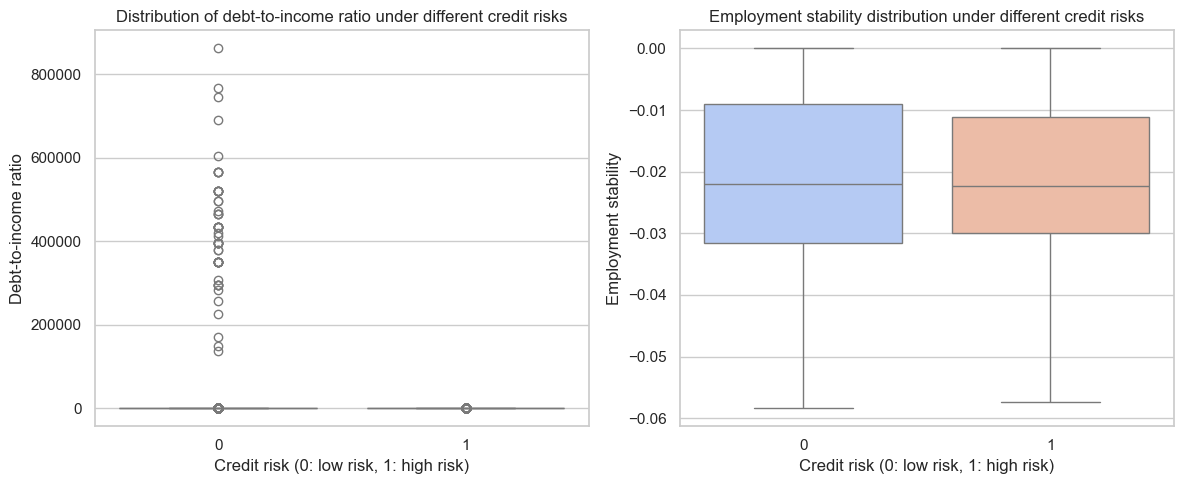

In [73]:
###################################################
# Identify high-risk groups for targeted strategies
###################################################

# Set Seaborn drawing style
sns.set(style="whitegrid")

# Suppose the Target variable is "Target" (where 0 means low risk and 1 means high risk)
if "Target" in df_encoded.columns:
    plt.figure(figsize=(12, 5))

    # Plot debt-to-income ratio distributions under different credit risks (box chart)
    plt.subplot(1, 2, 1)
    sns.boxplot(x="Target", y="Debt_to_Income_ratio", data=df_encoded, palette="coolwarm")
    plt.title("Distribution of debt-to-income ratio under different credit risks")
    plt.xlabel("Credit risk (0: low risk, 1: high risk)")
    plt.ylabel("Debt-to-income ratio")

    # Plot the distribution of employment stability under different credit risks (box chart)
    plt.subplot(1, 2, 2)
    sns.boxplot(x="Target", y="Employment_Stability", data=df_encoded, palette="coolwarm")
    plt.title("Employment stability distribution under different credit risks")
    plt.xlabel("Credit risk (0: low risk, 1: high risk)")
    plt.ylabel("Employment stability")

    plt.tight_layout()
    plt.show()
else:
    print("The 'Target' column was not found in the dataset, please confirm the target variable name.")



In [75]:
print("\n【Credit risk assessment suggestions from graphs】")
print("📌 「Left graph」: People with high credit risk (Target=1) have a wider distribution of debt-to-income ratios and a large number of extremely high values (outliers). The debt-to-income ratio of people with low credit risk (Target=0) is more concentrated, and most of the values are lower.Users with high debt to income ratios tend to be less able to repay.")
print("📌 Suggest: Stricter approval requirements for customers with debt-to-income ratios above a certain threshold.")
print("📌 「Right graph」: The overall distribution of employment stability for high credit risk (Target=1) is similar to that for low credit risk (Target=0), but: The employment stability of customers with high credit risk is more dispersed, and the employment stability of some customers is very low (with outlier points). The employment stability of customers with low credit risk is concentrated in higher values, indicating that they generally have more stable occupations. Some high credit risk customers have very low job stability (close to zero), indicating that they may change jobs frequently or work for too short a time.")
print("📌 Suggest: Additional scrutiny for clients with employment stability below a certain threshold.")


【Credit risk assessment suggestions from graphs】
📌 「Left graph」: People with high credit risk (Target=1) have a wider distribution of debt-to-income ratios and a large number of extremely high values (outliers). The debt-to-income ratio of people with low credit risk (Target=0) is more concentrated, and most of the values are lower.Users with high debt to income ratios tend to be less able to repay.
📌 Suggest: Stricter approval requirements for customers with debt-to-income ratios above a certain threshold.
📌 「Right graph」: The overall distribution of employment stability for high credit risk (Target=1) is similar to that for low credit risk (Target=0), but: The employment stability of customers with high credit risk is more dispersed, and the employment stability of some customers is very low (with outlier points). The employment stability of customers with low credit risk is concentrated in higher values, indicating that they generally have more stable occupations. Some high credit 

Debt-to-income ratio 75-quantile threshold: 2.00
25 quantile threshold of employment stability: -0.03
Risk group statistics：
Risk_Category
Low Risk         5383
Moderate Risk    3837
High Risk         489
Name: count, dtype: int64


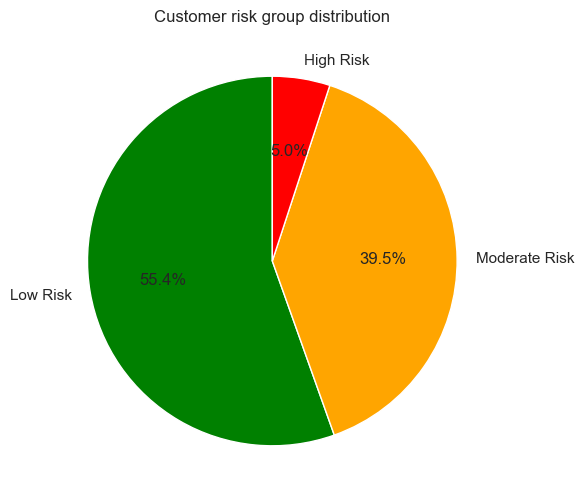

In [77]:
#############################################################
# Propose actionable insights for credit approval processes.
#############################################################

# Calculate quantile thresholds for debt-to-income ratios and employment stability
debt_threshold = df_encoded["Debt_to_Income_ratio"].quantile(0.75)
emp_stability_threshold = df_encoded["Employment_Stability"].quantile(0.25)

print(f"Debt-to-income ratio 75-quantile threshold: {debt_threshold:.2f}")
print(f"25 quantile threshold of employment stability: {emp_stability_threshold:.2f}")

# Risk is graded for each customer based on the above thresholds
def risk_category(row):
    # High risk: If the debt-to-income ratio is above the threshold and employment stability is below the threshold.
    if row["Debt_to_Income_ratio"] > debt_threshold and row["Employment_Stability"] < emp_stability_threshold:
        return "High Risk"
    # Moderate risk： If one of these conditions is met.
    elif row["Debt_to_Income_ratio"] > debt_threshold or row["Employment_Stability"] < emp_stability_threshold:
        return "Moderate Risk"
    # Low risk: Neither
    else:
        return "Low Risk"
        
df_encoded["Risk_Category"] = df_encoded.apply(risk_category, axis=1)

# View the number of clients by risk category
risk_counts = df_encoded["Risk_Category"].value_counts()
print("Risk group statistics：")
print(risk_counts)

# Visualize risk grouping results (Pie chart)
plt.figure(figsize=(6,6))
risk_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["green", "orange", "red"])
plt.title("Customer risk group distribution")
plt.ylabel("")
plt.show()


In [81]:
print("\n【Credit approval proposal】")
print("📌 High-risk customers: require stringent approval, require more financial and employment proof, raise interest rates or lower limits on loans, and strengthen post-loan monitoring.")
print("📌 Medium-risk customers: take appropriate approval measures, such as lending in stages and supplementing necessary supporting materials.")
print("📌 Low-risk customers: can simplify the approval process, give lower interest rates, attract high-quality customers.")
print("Through risk grouping and suggestion, we can develop personalized approval strategies for customers with different risk levels, thereby controlling risk while improving approval efficiency and customer experience during the credit approval process.")



【Credit approval proposal】
📌 High-risk customers: require stringent approval, require more financial and employment proof, raise interest rates or lower limits on loans, and strengthen post-loan monitoring.
📌 Medium-risk customers: take appropriate approval measures, such as lending in stages and supplementing necessary supporting materials.
📌 Low-risk customers: can simplify the approval process, give lower interest rates, attract high-quality customers.
Through risk grouping and suggestion, we can develop personalized approval strategies for customers with different risk levels, thereby controlling risk while improving approval efficiency and customer experience during the credit approval process.
